# 02 — Home Credit Default Risk — EDA & Feature Preparation for Modeling

**Scope of this notebook**: complete, professional EDA and final feature preparation, ending
**immediately before any model training**. No Logistic Regression, Decision Tree, Random Forest,
XGBoost, MLP, hyperparameter tuning, calibration, SHAP, or deployment happens here.

**Input**: `collected_dataset.csv` — the analytical table produced by `data_collection.ipynb`
(307,511 applicants × 629 features, one row per `SK_ID_CURR`).

## Why the step order below differs slightly from a naive "EDA then split" approach

Some EDA steps (target-vs-feature correlation, distributions used to justify feature decisions)
technically *use* `TARGET` and *use every row* — including rows that will end up in the Test set.
Computing those statistics on the full dataset before splitting is a mild but real form of
train/test contamination: decisions like "keep this column, it's correlated with the target" would
then be informed by data the model is never supposed to see during training or feature selection.

To keep this leakage-safe, the notebook is organized into two kinds of EDA:

1. **Structural EDA (Phase 1a, before the split)** — properties of the data that don't depend on
   `TARGET` or on which rows end up where: shape, dtypes, duplicates, identifiers, missingness,
   constant features, and a domain-knowledge leakage audit. Safe to compute on the full dataset.
2. **Statistical / target-relative EDA (Phase 1b, after the split)** — distributions, skewness,
   outliers, target correlation, redundancy analysis. Computed on the **training split only**.

The Test set is created early (Phase 3, right after Phase 1a) and is not touched again until a
final held-out evaluation in a future modeling notebook.

## Deliverables produced by this notebook
- Cleaned analytical dataset with the final ML feature list
- EDA figures and an EDA decision log (kept/dropped + reason, per column)
- `X_train`, `y_train`, `X_test`, `y_test`
- A fitted, reusable `sklearn` preprocessing pipeline
- A documented Stratified K-Fold + class-imbalance strategy


## 0. Imports & configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import json
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

RANDOM_STATE = 42

# Path to the analytical dataset produced by data_collection.ipynb
DATA_PATH = r"C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\src\data\collected_dataset.csv"

OUTPUT_DIR = r"C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\reports"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


## 1. Load data

In [4]:
df = pd.read_csv(DATA_PATH)
print("Loaded shape:", df.shape)
df.head()


Loaded shape: (307511, 629)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,PREV_INST_DAYS_ENTRY_PAYMENT_STD_MAX,PREV_INST_AMT_INSTALMENT_MEAN_MEAN,PREV_INST_AMT_INSTALMENT_MEAN_MAX,PREV_INST_AMT_INSTALMENT_MIN_MEAN,PREV_INST_AMT_INSTALMENT_MIN_MAX,PREV_INST_AMT_INSTALMENT_MAX_MEAN,PREV_INST_AMT_INSTALMENT_MAX_MAX,PREV_INST_AMT_INSTALMENT_SUM_MEAN,PREV_INST_AMT_INSTALMENT_SUM_MAX,PREV_INST_AMT_INSTALMENT_STD_MEAN,PREV_INST_AMT_INSTALMENT_STD_MAX,PREV_INST_AMT_PAYMENT_MEAN_MEAN,PREV_INST_AMT_PAYMENT_MEAN_MAX,PREV_INST_AMT_PAYMENT_MIN_MEAN,PREV_INST_AMT_PAYMENT_MIN_MAX,PREV_INST_AMT_PAYMENT_MAX_MEAN,PREV_INST_AMT_PAYMENT_MAX_MAX,PREV_INST_AMT_PAYMENT_SUM_MEAN,PREV_INST_AMT_PAYMENT_SUM_MAX,PREV_INST_AMT_PAYMENT_STD_MEAN,PREV_INST_AMT_PAYMENT_STD_MAX,PREV_INST_COUNT_MEAN,PREV_INST_COUNT_MAX,PREV_NAME_CONTRACT_TYPE_NUNIQUE,PREV_WEEKDAY_APPR_PROCESS_START_NUNIQUE,PREV_FLAG_LAST_APPL_PER_CONTRACT_NUNIQUE,PREV_NAME_CASH_LOAN_PURPOSE_NUNIQUE,PREV_NAME_CONTRACT_STATUS_NUNIQUE,PREV_NAME_PAYMENT_TYPE_NUNIQUE,PREV_CODE_REJECT_REASON_NUNIQUE,PREV_NAME_TYPE_SUITE_NUNIQUE,PREV_NAME_CLIENT_TYPE_NUNIQUE,PREV_NAME_GOODS_CATEGORY_NUNIQUE,PREV_NAME_PORTFOLIO_NUNIQUE,PREV_NAME_PRODUCT_TYPE_NUNIQUE,PREV_CHANNEL_TYPE_NUNIQUE,PREV_NAME_SELLER_INDUSTRY_NUNIQUE,PREV_NAME_YIELD_GROUP_NUNIQUE,PREV_PRODUCT_COMBINATION_NUNIQUE,PREV_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,172.058880,11559.247,11559.247,9251.775,9251.775,53093.746,53093.746,219625.700,219625.700,10058.03800,10058.03800,11559.247,11559.247,9251.7750,9251.775,53093.746,53093.746,219625.700,219625.700,10058.0380,10058.0380,19.000000,19.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,...,111.245940,78558.484,164425.340,56431.860,98356.990,210713.450,560835.400,539621.560,1150977.400,58313.69000,174800.39000,78558.484,164425.340,56431.8600,98356.990,210713.450,560835.400,539621.560,1150977.400,58313.6900,174800.3900,8.333333,12.0,2.0,3.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,3.0,2.0,2.0,3.0,3.0,2.0,3.0,3.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,...,34.019604,7096.155,7096.155,5357.250,5357.250,10573.965,10573.965,21288.465,21288.465,3011.87180,3011.87180,7096.155,7096.155,5357.2500,5357.250,10573.965,10573.965,21288.465,21288.465,3011.8718,3011.8718,3.000000,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,...,92.483330,241944.230,691786.900,241099.110,691786.900,245324.690,691786.900,335717.780,691786.900,2834.60180,5669.20360,241944.230,691786.900,241099.1100,691786.

## 2. Phase 1a — Structural EDA (safe to compute on the full dataset)

### 2.1 Data audit
Shape, dtypes, duplicate rows/keys, and automatic identification of identifier columns
(Home Credit's own `SK_ID_*` naming convention — the same rule used in the data-collection notebook).

In [5]:
ID_PATTERN = re.compile(r"^SK_ID_", re.IGNORECASE)
id_columns = [c for c in df.columns if ID_PATTERN.match(c)]

print("Shape:", df.shape)
print("Identifier columns (excluded from ML features):", id_columns)
print()
print("Dtype breakdown:")
print(df.dtypes.value_counts())
print()

numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_all = [c for c in numeric_cols_all if c not in id_columns and c != "TARGET"]
categorical_cols_all = df.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Numeric feature candidates: {len(numeric_cols_all)}")
print(f"Categorical feature candidates: {len(categorical_cols_all)}")
print()

n_dupe_rows = df.duplicated().sum()
n_dupe_ids = df["SK_ID_CURR"].duplicated().sum()
print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicated SK_ID_CURR: {n_dupe_ids}")
assert n_dupe_rows == 0 and n_dupe_ids == 0, "Unexpected duplicates - investigate before continuing."

print()
print("Unique-value count summary (numeric candidates):")
print(df[numeric_cols_all].nunique().describe())


Shape: (307511, 629)
Identifier columns (excluded from ML features): ['SK_ID_CURR']

Dtype breakdown:
float64    572
int64       41
object      16
Name: count, dtype: int64

Numeric feature candidates: 611
Categorical feature candidates: 16

Fully duplicated rows: 0
Duplicated SK_ID_CURR: 0

Unique-value count summary (numeric candidates):
count       611.000000
mean      32549.818331
std       61961.755009
min           1.000000
25%          96.500000
50%        2945.000000
75%       38748.000000
max      285452.000000
dtype: float64


### 2.2 Missingness analysis (structural)

Missing % per column, sorted, plus a specific check for "history-related missingness": applicants
with **zero prior loans** will naturally have `NaN` in every `BUREAU_*`/`PREV_*` aggregated column
(there was nothing to aggregate) - this is a meaningful signal, not corrupted data, and is handled
via a `HAS_BUREAU_HISTORY` / `HAS_PREVIOUS_APPLICATION` flag rather than being imputed away silently.

Columns with at least some missing values: 574 / 629

Top 20 by % missing:
PREV_RATE_INTEREST_PRIMARY_STD                 99.94
PREV_RATE_INTEREST_PRIVILEGED_STD              99.94
PREV_RATE_INTEREST_PRIVILEGED_MEAN             98.50
PREV_RATE_INTEREST_PRIVILEGED_MAX              98.50
PREV_RATE_INTEREST_PRIVILEGED_MIN              98.50
PREV_RATE_INTEREST_PRIMARY_MIN                 98.50
PREV_RATE_INTEREST_PRIMARY_MEAN                98.50
PREV_RATE_INTEREST_PRIMARY_MAX                 98.50
PREV_CC_AMT_PAYMENT_CURRENT_STD_MEAN           82.96
PREV_CC_AMT_PAYMENT_CURRENT_STD_MAX            82.96
PREV_CC_AMT_DRAWINGS_ATM_CURRENT_STD_MEAN      82.93
PREV_CC_CNT_DRAWINGS_POS_CURRENT_STD_MEAN      82.93
PREV_CC_CNT_DRAWINGS_ATM_CURRENT_STD_MEAN      82.93
PREV_CC_CNT_DRAWINGS_OTHER_CURRENT_STD_MAX     82.93
PREV_CC_CNT_DRAWINGS_ATM_CURRENT_STD_MAX       82.93
PREV_CC_AMT_DRAWINGS_ATM_CURRENT_STD_MAX       82.93
PREV_CC_AMT_DRAWINGS_OTHER_CURRENT_STD_MAX     82.93
PREV_CC_AMT_DRAWINGS_OTH

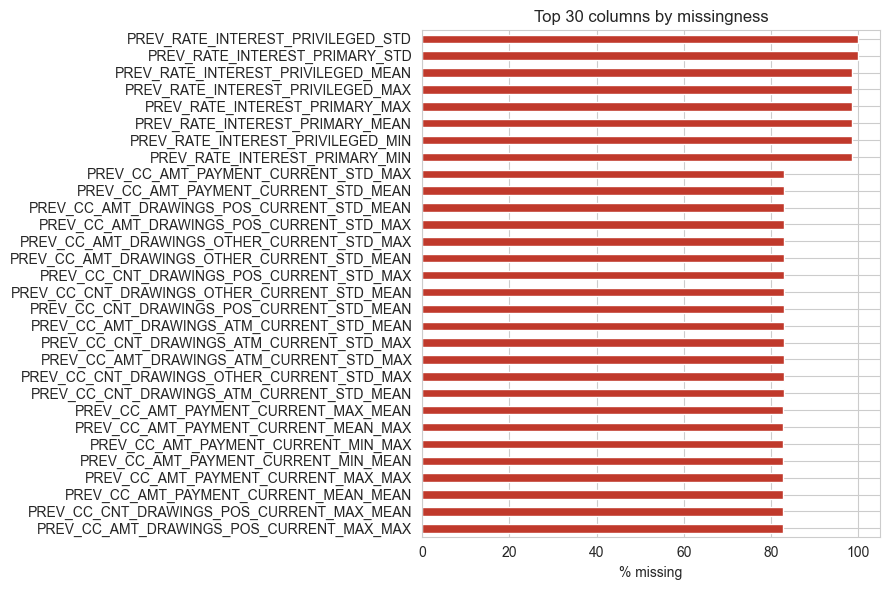

In [6]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

print(f"Columns with at least some missing values: {len(missing_pct)} / {df.shape[1]}")
print()
print("Top 20 by % missing:")
print(missing_pct.head(20).round(2))

fig, ax = plt.subplots(figsize=(9, 6))
missing_pct.head(30).sort_values().plot(kind="barh", ax=ax, color="#c0392b")
ax.set_xlabel("% missing")
ax.set_title("Top 30 columns by missingness")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "missingness_top30.png"), dpi=120)
plt.show()


In [9]:
# History-related missingness: does a client have any bureau / previous-application history at all?
bureau_cols = [c for c in df.columns if c.startswith("BUREAU_")]
prev_cols = [c for c in df.columns if c.startswith("PREV_")]

df["HAS_BUREAU_HISTORY"] = df[bureau_cols].notnull().any(axis=1).astype(int) if bureau_cols else 1
df["HAS_PREVIOUS_APPLICATION"] = df[prev_cols].notnull().any(axis=1).astype(int) if prev_cols else 1

print("Applicants with NO bureau history:", (df['HAS_BUREAU_HISTORY'] == 0).sum(),
      f"({(df['HAS_BUREAU_HISTORY'] == 0).mean():.1%})")
print("Applicants with NO previous Home Credit application:", (df['HAS_PREVIOUS_APPLICATION'] == 0).sum(),
      f"({(df['HAS_PREVIOUS_APPLICATION'] == 0).mean():.1%})")
print()
print("These two flags are informative engineered features in their own right and are kept.")


Applicants with NO bureau history: 44020 (14.3%)
Applicants with NO previous Home Credit application: 16454 (5.4%)

These two flags are informative engineered features in their own right and are kept.


### 2.3 Constant and near-constant feature detection

A column with (almost) no variation carries (almost) no information for any model. We flag:
- **Constant**: exactly one unique non-null value.
- **Near-constant**: one category/value accounts for ≥ 99.5% of non-null rows (a single global,
  automated threshold — not a per-column manual judgement call).

In [10]:
NEAR_CONSTANT_THRESHOLD = 0.995

constant_cols = []
near_constant_cols = []

for col in numeric_cols_all + categorical_cols_all:
    value_counts = df[col].value_counts(dropna=True, normalize=True)
    if len(value_counts) == 0:
        continue
    if len(value_counts) == 1:
        constant_cols.append(col)
    elif value_counts.iloc[0] >= NEAR_CONSTANT_THRESHOLD:
        near_constant_cols.append((col, value_counts.index[0], value_counts.iloc[0]))

print(f"Fully constant columns ({len(constant_cols)}):", constant_cols)
print()
print(f"Near-constant columns (dominant value >= {NEAR_CONSTANT_THRESHOLD:.1%}):")
for col, val, frac in near_constant_cols:
    print(f"  {col:<40} dominant value = {val!r:<15} ({frac:.3%})")


Fully constant columns (4): ['PREV_CC_SK_DPD_MIN_MEAN', 'PREV_CC_SK_DPD_MIN_MAX', 'PREV_CC_SK_DPD_DEF_MIN_MEAN', 'PREV_CC_SK_DPD_DEF_MIN_MAX']

Near-constant columns (dominant value >= 99.5%):
  FLAG_MOBIL                               dominant value = np.int64(1)     (100.000%)
  FLAG_CONT_MOBILE                         dominant value = np.int64(1)     (99.813%)
  FLAG_DOCUMENT_2                          dominant value = np.int64(0)     (99.996%)
  FLAG_DOCUMENT_4                          dominant value = np.int64(0)     (99.992%)
  FLAG_DOCUMENT_7                          dominant value = np.int64(0)     (99.981%)
  FLAG_DOCUMENT_9                          dominant value = np.int64(0)     (99.610%)
  FLAG_DOCUMENT_10                         dominant value = np.int64(0)     (99.998%)
  FLAG_DOCUMENT_11                         dominant value = np.int64(0)     (99.609%)
  FLAG_DOCUMENT_12                         dominant value = np.int64(0)     (99.999%)
  FLAG_DOCUMENT_13              

### 2.4 Leakage audit (domain-based, no TARGET statistics involved)

This check is rule-based, not statistical, so it's safe to run before the split. It covers the
four leakage categories from the project brief:

1. **Identifier columns** — already isolated above (`id_columns`), always excluded from ML features.
2. **Target-derived features** — any column other than `TARGET` itself whose name suggests it was
   derived from the outcome (defensive pattern match on `"TARGET"` in the name).
3. **Post-loan information** — `bureau`/`previous_application` (and children) describe loans that
   are **separate from and prior to** the current application - this is legitimate credit history,
   not leakage, as documented in `data_collection.ipynb`. There is no column in this dataset that
   describes the outcome of the *current* loan after the fact (Home Credit's public release does
   not include post-decision servicing data for the loan being scored).
4. **Temporal leakage** — none of the `DAYS_*` fields in this dataset are computed relative to a
   future event, they're offsets from the application date (`DAYS_BIRTH`, `DAYS_EMPLOYED`, ...).

We still run an automated correlation-based *smell test* here using only non-target-derived checks
that don't require the split (name-pattern matching); the statistical smell test against `TARGET`
happens later, on the training split only, in Section 4.

In [11]:
suspicious_name_cols = [c for c in df.columns if "TARGET" in c.upper() and c != "TARGET"]
print("Columns with 'TARGET' in the name (excluding TARGET itself):", suspicious_name_cols)
assert len(suspicious_name_cols) == 0, "Investigate before continuing - possible target leakage by naming."

print()
print("[OK] No target-derived columns detected by name.")
print("[OK] bureau_/previous_application-derived columns represent prior, separate loans - not leakage (see data_collection.ipynb).")
print("[OK] No post-decision servicing columns for the current loan exist in this public dataset.")
print("[OK] All DAYS_* fields are offsets from the application date, not future events.")

confirmed_leakage_cols = suspicious_name_cols  # empty here, kept as a named list for the decision log


Columns with 'TARGET' in the name (excluding TARGET itself): []

[OK] No target-derived columns detected by name.
[OK] bureau_/previous_application-derived columns represent prior, separate loans - not leakage (see data_collection.ipynb).
[OK] No post-decision servicing columns for the current loan exist in this public dataset.
[OK] All DAYS_* fields are offsets from the application date, not future events.


## 3. Phase 3 — Train/Test split (locked from here on)

Split now, using only the structural information gathered above (ids, constants, confirmed
leakage) — **before** any statistic that involves `TARGET` beyond stratification itself is computed
on a per-feature basis. 80/20, stratified on `TARGET` so the imbalance ratio is preserved in both sets.

**From this point on, `test_df` is not used for feature selection, preprocessing fitting, imbalance
strategy, or any decision-making — only for a final held-out evaluation in a future notebook.**

In [12]:
feature_candidates = [c for c in df.columns if c not in id_columns + ["TARGET"]]

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["TARGET"],
    random_state=RANDOM_STATE,
)

print(f"Train shape: {train_df.shape}  ({len(train_df) / len(df):.1%})")
print(f"Test shape:  {test_df.shape}  ({len(test_df) / len(df):.1%})")
print()
print("Train default rate:", train_df["TARGET"].mean().round(4))
print("Test default rate: ", test_df["TARGET"].mean().round(4))

assert train_df["SK_ID_CURR"].is_unique and test_df["SK_ID_CURR"].is_unique
assert set(train_df["SK_ID_CURR"]).isdisjoint(set(test_df["SK_ID_CURR"])), "Train/Test overlap detected!"
print("\n[OK] Train and Test are disjoint on SK_ID_CURR, stratification preserved the default rate in both.")

# Lock the test IDs now, as a hard reference - any code touching test_df by anything other than
# SK_ID_CURR lookup from here on should be treated as a bug.
LOCKED_TEST_IDS = set(test_df["SK_ID_CURR"])


Train shape: (246008, 631)  (80.0%)
Test shape:  (61503, 631)  (20.0%)

Train default rate: 0.0807
Test default rate:  0.0807

[OK] Train and Test are disjoint on SK_ID_CURR, stratification preserved the default rate in both.


## 4. Phase 1b — Statistical / target-relative EDA (training split only)

Everything from here until the decision log uses **`train_df` exclusively**.

### 4.1 Target distribution & imbalance ratio

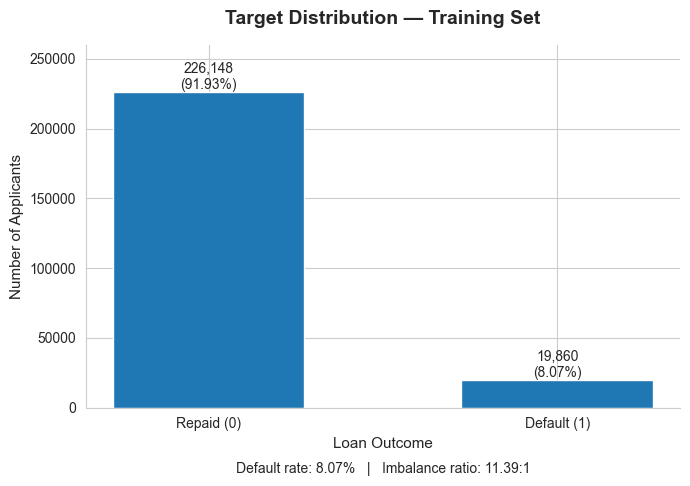

In [17]:
# Target distribution — Train set
target_counts = train_df["TARGET"].value_counts().sort_index()

default_rate = train_df["TARGET"].mean()
imbalance_ratio = target_counts[0] / target_counts[1]

labels = ["Repaid (0)", "Default (1)"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    labels,
    target_counts.values,
    width=0.55
)

# Add count and percentage above each bar
total = target_counts.sum()

for bar, count in zip(bars, target_counts.values):
    percentage = count / total * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Target Distribution — Training Set",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Number of Applicants", fontsize=11)

ax.set_xlabel("Loan Outcome", fontsize=11)

ax.set_ylim(0, target_counts.max() * 1.15)

# Remove unnecessary top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add imbalance information below the chart
ax.text(
    0.5,
    -0.18,
    f"Default rate: {default_rate:.2%}   |   Imbalance ratio: {imbalance_ratio:.2f}:1",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "target_distribution.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 4.2 Numerical analysis: descriptive statistics, distributions, skewness, outliers

Outliers are counted with the IQR rule (1.5×IQR beyond Q1/Q3) purely for reporting - **no rows or
values are removed at this stage**, since aggressive outlier removal on a credit-risk dataset can
discard exactly the extreme-but-real cases (very high income, very large previous loans) that
matter most for default prediction.

In [18]:
numeric_cols = [c for c in numeric_cols_all if c in train_df.columns]

desc = train_df[numeric_cols].describe().T
skewness = train_df[numeric_cols].skew().rename("skewness")

def iqr_outlier_pct(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).mean() * 100

outlier_pct = train_df[numeric_cols].apply(iqr_outlier_pct).rename("outlier_pct_iqr")

numeric_summary = pd.concat([desc[["mean", "std", "min", "max"]], skewness, outlier_pct], axis=1)
numeric_summary = numeric_summary.sort_values("outlier_pct_iqr", ascending=False)

print("Most skewed / outlier-heavy numeric features:")
print(numeric_summary.head(15).round(3))


Most skewed / outlier-heavy numeric features:
                                                 mean         std       min           max  skewness  outlier_pct_iqr
BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM            8014.967  342476.624       0.0  1.159872e+08   287.473           24.441
DAYS_EMPLOYED                               63581.164  141081.697  -17912.0  3.652430e+05     1.670           23.442
BUREAU_DAYS_CREDIT_ENDDATE_MAX               4440.917    9358.653  -41875.0  3.119900e+04     2.239           19.887
PREV_DAYS_FIRST_DUE_MAX                     41265.919  116493.992   -2891.0  3.652430e+05     2.421           19.815
PREV_CC_MONTHS_BALANCE_SUM_MEAN              -886.116    1377.917   -4656.0 -1.000000e+00    -1.575           19.389
PREV_CC_MONTHS_BALANCE_SUM_MAX               -882.413    1377.843   -4656.0 -1.000000e+00    -1.582           19.312
BUREAU_DAYS_CREDIT_UPDATE_MAX                -141.072     340.038   -2910.0  3.720000e+02    -3.891           19.259
BUREAU_DAYS_CREDIT

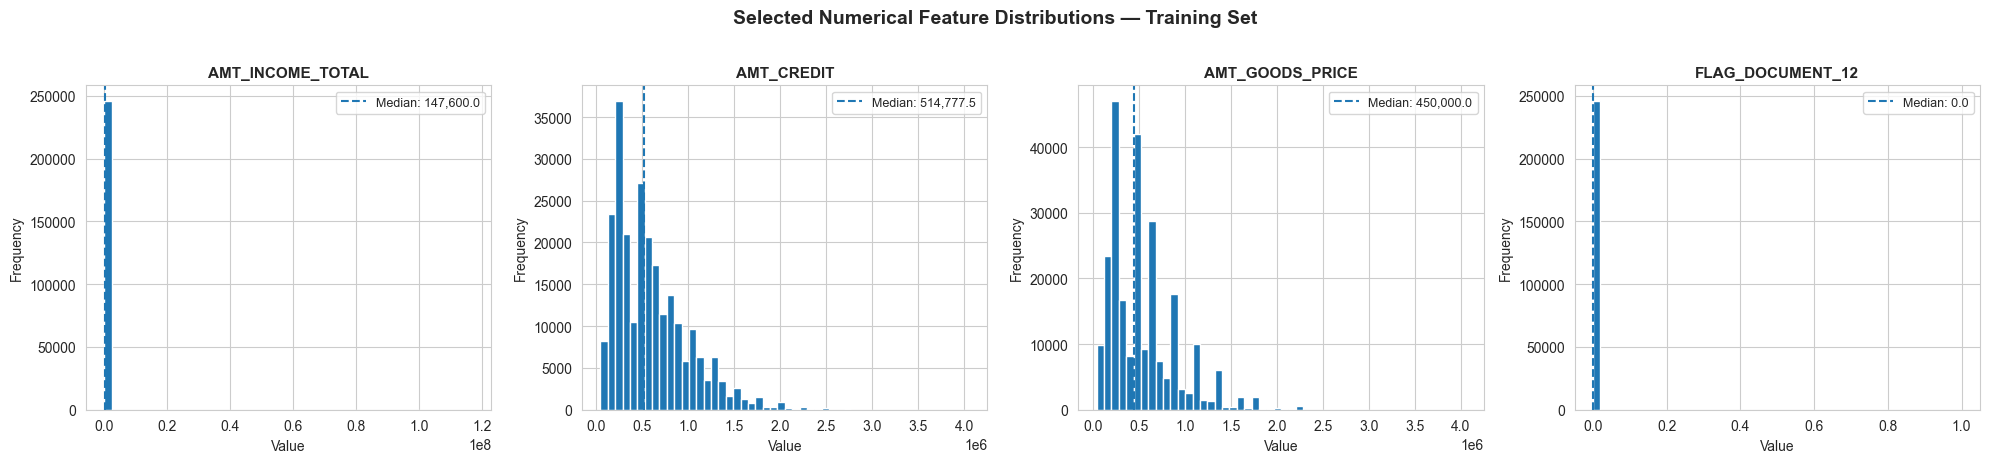

In [21]:
# Visualize selected business-relevant and highly skewed numeric features

business_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE"
]

highlight_cols = [c for c in business_cols if c in numeric_cols]

# Add highly skewed features if fewer than 4 business features are available
if len(highlight_cols) < 4:
    extra_cols = [
        c for c in numeric_summary.sort_values(
            "skewness",
            key=lambda s: s.abs(),
            ascending=False
        ).index
        if c not in highlight_cols
    ]
    highlight_cols += extra_cols[:4 - len(highlight_cols)]

highlight_cols = highlight_cols[:4]

if highlight_cols:
    fig, axes = plt.subplots(
        1,
        len(highlight_cols),
        figsize=(5 * len(highlight_cols), 4.5)
    )

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, highlight_cols):
        values = train_df[col].dropna()

        ax.hist(values, bins=50)

        median_value = values.median()
        ax.axvline(
            median_value,
            linestyle="--",
            linewidth=1.5,
            label=f"Median: {median_value:,.1f}"
        )

        ax.set_title(
            col,
            fontsize=11,
            fontweight="bold"
        )
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=9)

    fig.suptitle(
        "Selected Numerical Feature Distributions — Training Set",
        fontsize=14,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(FIGURES_DIR, "numeric_distributions.png"),
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

### 4.3 Categorical analysis: cardinality, frequencies, rare categories

A category is flagged as **rare** if it accounts for less than 1% of training rows - useful to know
before encoding (rare categories can blow up one-hot dimensionality and are prone to being unseen
in some CV folds).

In [22]:
RARE_CATEGORY_THRESHOLD = 0.01

categorical_cols = [c for c in categorical_cols_all if c in train_df.columns]
cat_summary_rows = []
for col in categorical_cols:
    vc = train_df[col].value_counts(normalize=True, dropna=True)
    rare_categories = vc[vc < RARE_CATEGORY_THRESHOLD].index.tolist()
    cat_summary_rows.append({
        "column": col,
        "cardinality": train_df[col].nunique(dropna=True),
        "missing_pct": train_df[col].isnull().mean() * 100,
        "top_category": vc.index[0] if len(vc) else None,
        "top_category_pct": vc.iloc[0] * 100 if len(vc) else None,
        "n_rare_categories": len(rare_categories),
    })

categorical_summary = pd.DataFrame(cat_summary_rows).sort_values("cardinality", ascending=False)
print(categorical_summary.round(2).to_string(index=False))


                    column  cardinality  missing_pct                  top_category  top_category_pct  n_rare_categories
         ORGANIZATION_TYPE           58         0.00        Business Entity Type 3             22.13                 41
           OCCUPATION_TYPE           18        31.28                      Laborers             26.18                  5
          NAME_INCOME_TYPE            8         0.00                       Working             51.64                  4
           NAME_TYPE_SUITE            7         0.42                 Unaccompanied             81.15                  3
        WALLSMATERIAL_MODE            7        50.80                         Panel             43.67                  0
WEEKDAY_APPR_PROCESS_START            7         0.00                       TUESDAY             17.55                  0
        NAME_FAMILY_STATUS            6         0.00                       Married             63.88                  1
         NAME_HOUSING_TYPE            6 

### 4.4 Target-focused analysis (Train only)

- **Numeric vs TARGET**: point-biserial correlation (equivalent to Pearson correlation against a
  0/1 target) — a standard, appropriate measure of linear association with a binary outcome.
- **Categorical vs TARGET**: default rate per category, to see which categories separate the classes.

This is the step that most directly informs the decision log — and it is **only ever computed on
`train_df`**, per Phase 3's rule.

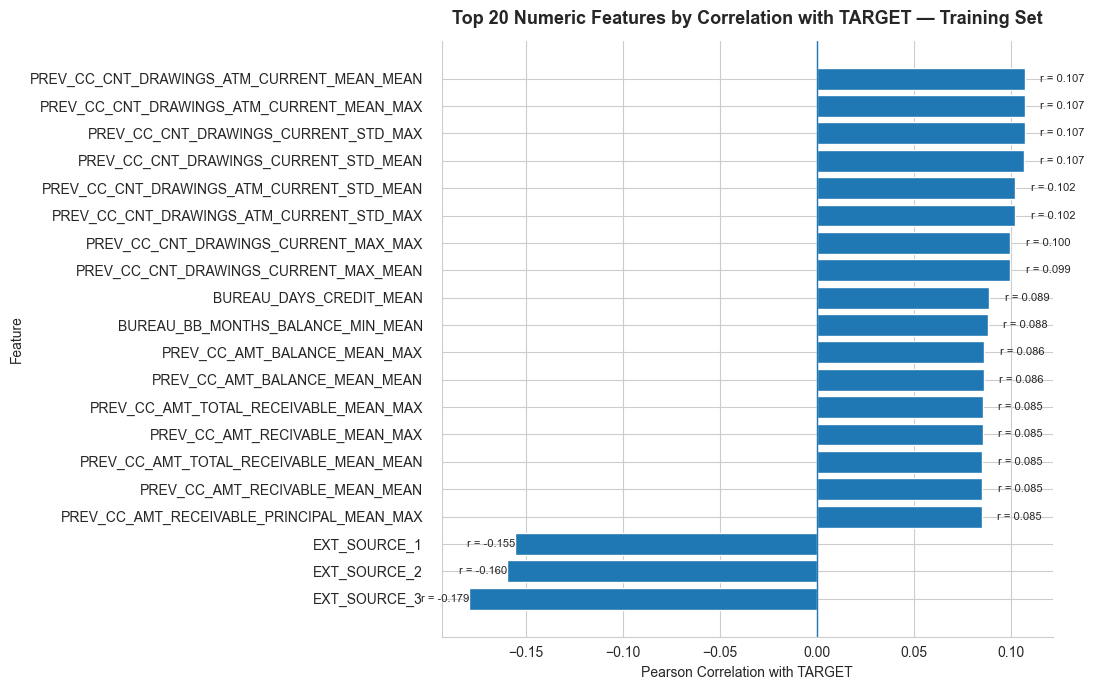

In [33]:
fig, ax = plt.subplots(figsize=(11, 7))

top_corr = target_corr.head(20).sort_values()
bars = ax.barh(top_corr.index, top_corr.values)

ax.axvline(0, linewidth=1)

for bar, value in zip(bars, top_corr.values):

    if value < 0:
        # Negative values: place label farther to the left
        x = value - 0.0001
        ha = "right"
    else:
        # Positive values: place label slightly to the right
        x = value + 0.008
        ha = "left"

    ax.text(
        x,
        bar.get_y() + bar.get_height() / 2,
        f"r = {value:.3f}",
        va="center",
        ha=ha,
        fontsize=8
    )

ax.set_title(
    "Top 20 Numeric Features by Correlation with TARGET — Training Set",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Pearson Correlation with TARGET")
ax.set_ylabel("Feature")

ax.tick_params(axis="y", pad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "target_correlation_top20.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [35]:
# Categorical vs TARGET: default rate per category (Train only)
for col in categorical_cols[:6]:  # first few for inline inspection; full results go in the decision log
    rate_by_cat = train_df.groupby(col)["TARGET"].mean().sort_values(ascending=False)
    print(f"\n{col} — default rate by category:")
    print((rate_by_cat * 100).round(2).astype(str) + "%")



NAME_CONTRACT_TYPE — default rate by category:
NAME_CONTRACT_TYPE
Cash loans         8.34%
Revolving loans    5.49%
Name: TARGET, dtype: object

CODE_GENDER — default rate by category:
CODE_GENDER
M      10.14%
F        7.0%
XNA      0.0%
Name: TARGET, dtype: object

FLAG_OWN_CAR — default rate by category:
FLAG_OWN_CAR
N    8.48%
Y    7.27%
Name: TARGET, dtype: object

FLAG_OWN_REALTY — default rate by category:
FLAG_OWN_REALTY
N    8.31%
Y    7.97%
Name: TARGET, dtype: object

NAME_TYPE_SUITE — default rate by category:
NAME_TYPE_SUITE
Other_B            9.71%
Other_A            8.75%
Group of people     8.6%
Unaccompanied      8.19%
Spouse, partner    7.87%
Family             7.45%
Children           7.26%
Name: TARGET, dtype: object

NAME_INCOME_TYPE — default rate by category:
NAME_INCOME_TYPE
Unemployed              29.41%
Working                  9.54%
Commercial associate     7.59%
State servant            5.85%
Pensioner                5.36%
Businessman               0.0%
Mat

### 4.5 Feature relationship / redundancy analysis (Train only)

Pairs of numeric features with |correlation| ≥ 0.95 are flagged as **redundant candidates**. Per
the brief ("keep useful features even if they have moderate ... correlation"), these are **not
automatically dropped** — multicollinearity mainly hurts linear models (handled at model-training
time, e.g. regularization) and is largely harmless for tree-based models. They're recorded in the
decision log for visibility.

In [36]:
REDUNDANCY_THRESHOLD = 0.95

corr_matrix = train_df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
)
redundant_pairs = redundant_pairs[redundant_pairs["abs_corr"] >= REDUNDANCY_THRESHOLD].sort_values(
    "abs_corr", ascending=False
)

print(f"Highly correlated feature pairs (|corr| >= {REDUNDANCY_THRESHOLD}): {len(redundant_pairs)}")
print(redundant_pairs.to_string(index=False))

redundant_feature_notes = {}
for _, row in redundant_pairs.iterrows():
    redundant_feature_notes.setdefault(row["feature_2"], []).append(
        f"{row['feature_1']} (corr={row['abs_corr']:.3f})"
    )


Highly correlated feature pairs (|corr| >= 0.95): 597
                                   feature_1                                   feature_2  abs_corr
 PREV_CC_CNT_DRAWINGS_OTHER_CURRENT_MIN_MEAN  PREV_CC_CNT_DRAWINGS_OTHER_CURRENT_MIN_MAX  1.000000
              PREV_CC_AMT_RECIVABLE_MIN_MEAN       PREV_CC_AMT_TOTAL_RECEIVABLE_MIN_MEAN  1.000000
               PREV_CC_AMT_RECIVABLE_MIN_MAX        PREV_CC_AMT_TOTAL_RECEIVABLE_MIN_MAX  1.000000
                PREV_POS_SK_DPD_DEF_MIN_MEAN                 PREV_POS_SK_DPD_DEF_MIN_MAX  1.000000
 PREV_CC_AMT_DRAWINGS_OTHER_CURRENT_MIN_MEAN  PREV_CC_AMT_DRAWINGS_OTHER_CURRENT_MIN_MAX  1.000000
             PREV_CC_MONTHS_BALANCE_MAX_MEAN              PREV_CC_MONTHS_BALANCE_MAX_MAX  1.000000
            BUREAU_BB_MONTHS_BALANCE_STD_MAX                         BUREAU_BB_COUNT_MAX  1.000000
              PREV_CC_AMT_RECIVABLE_MEAN_MAX       PREV_CC_AMT_TOTAL_RECEIVABLE_MEAN_MAX  1.000000
             PREV_CC_AMT_RECIVABLE_MEAN_MEAN      PREV_

## 5. EDA decision log

One row per candidate feature, with every signal gathered above and a single automated decision.
**Drop rules are global thresholds applied uniformly, not a per-column manual judgement call:**

| Rule | Threshold | Rationale |
|---|---|---|
| Identifier | any `SK_ID_*` column | Never a measurement, always excluded |
| Confirmed leakage | name-pattern / domain audit | Direct target leakage |
| Constant | exactly 1 unique value | Zero information |
| Near-constant | dominant value ≥ 99.5% | Effectively zero information |
| Extremely high missing | ≥ 95% missing **and not otherwise justified** | Too sparse to learn from reliably |

Everything else is **kept**, regardless of moderate missingness or moderate/weak correlation with
`TARGET` — per the brief's explicit instruction not to prune features just because their individual
association looks weak (tree-based models in particular can still exploit weak/nonlinear signals).

In [37]:
EXTREME_MISSING_THRESHOLD = 0.95

decision_rows = []
all_candidate_cols = [c for c in df.columns if c not in id_columns + ["TARGET"]]

missing_pct_full = df[all_candidate_cols].isnull().mean()

for col in all_candidate_cols:
    is_constant = col in constant_cols
    is_near_constant = col in [c for c, _, _ in near_constant_cols]
    is_leakage = col in confirmed_leakage_cols
    miss_pct = missing_pct_full.get(col, 0.0)
    is_extreme_missing = miss_pct >= EXTREME_MISSING_THRESHOLD

    corr_with_target = target_corr.get(col, np.nan) if col in numeric_cols else np.nan
    redundant_with = "; ".join(redundant_feature_notes.get(col, [])) or None

    if is_leakage:
        decision, reason = "drop", "confirmed leakage (name-pattern/domain audit)"
    elif is_constant:
        decision, reason = "drop", "constant (single unique value)"
    elif is_near_constant:
        decision, reason = "drop", "near-constant (dominant value >= 99.5%)"
    elif is_extreme_missing:
        decision, reason = "drop", f"extremely high missing ({miss_pct:.1%} >= {EXTREME_MISSING_THRESHOLD:.0%}), unreliable"
    else:
        decision = "keep"
        reason_parts = [f"missing={miss_pct:.1%}"]
        if not pd.isna(corr_with_target):
            reason_parts.append(f"target_corr={corr_with_target:.3f}")
        if redundant_with:
            reason_parts.append(f"redundant_with=[{redundant_with}] (kept, monitor for linear models)")
        reason = "; ".join(reason_parts)

    decision_rows.append({
        "feature": col,
        "dtype": str(df[col].dtype),
        "missing_pct": round(miss_pct * 100, 2),
        "is_constant": is_constant,
        "is_near_constant": is_near_constant,
        "is_leakage": is_leakage,
        "target_corr": round(corr_with_target, 4) if not pd.isna(corr_with_target) else None,
        "redundant_with": redundant_with,
        "decision": decision,
        "reason": reason,
    })

decision_log = pd.DataFrame(decision_rows).sort_values(["decision", "feature"])
print(decision_log["decision"].value_counts())
print()
print(decision_log.head(15).to_string(index=False))


decision
keep    586
drop     43
Name: count, dtype: int64

                          feature   dtype  missing_pct  is_constant  is_near_constant  is_leakage  target_corr redundant_with decision                                  reason
BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN float64        14.31        False              True       False      -0.0004           None     drop near-constant (dominant value >= 99.5%)
    BUREAU_CNT_CREDIT_PROLONG_MIN float64        14.31        False              True       False      -0.0023           None     drop near-constant (dominant value >= 99.5%)
   BUREAU_CREDIT_CURRENCY_NUNIQUE float64        14.31        False              True       False      -0.0035           None     drop near-constant (dominant value >= 99.5%)
    BUREAU_CREDIT_DAY_OVERDUE_MIN float64        14.31        False              True       False       0.0048           None     drop near-constant (dominant value >= 99.5%)
                 FLAG_CONT_MOBILE   int64         0.00        Fal

## 6. Final ML feature list

Derived directly and automatically from the decision log above — no manual column-by-column
override.

In [38]:
final_feature_list = decision_log.loc[decision_log["decision"] == "keep", "feature"].tolist()
final_numeric_features = [c for c in final_feature_list if c in numeric_cols_all]
final_categorical_features = [c for c in final_feature_list if c in categorical_cols_all]
# HAS_BUREAU_HISTORY / HAS_PREVIOUS_APPLICATION were engineered in section 2.2 - ensure they're included
for engineered_col in ["HAS_BUREAU_HISTORY", "HAS_PREVIOUS_APPLICATION"]:
    if engineered_col in df.columns and engineered_col not in final_numeric_features:
        final_numeric_features.append(engineered_col)
        if engineered_col not in final_feature_list:
            final_feature_list.append(engineered_col)

print(f"Final feature count: {len(final_feature_list)} "
      f"({len(final_numeric_features)} numeric + {len(final_categorical_features)} categorical)")
print(f"Dropped: {df.shape[1] - len(id_columns) - 1 - len(final_feature_list)} columns "
      f"(out of {df.shape[1] - len(id_columns) - 1} candidates, excluding IDs and TARGET)")


Final feature count: 586 (570 numeric + 16 categorical)
Dropped: 43 columns (out of 629 candidates, excluding IDs and TARGET)


## 7. Rebuild X/y for Train and Test using the final feature list

Test rows are identified purely by the `SK_ID_CURR` values locked in Section 3 — Test's own
statistics played no part in the feature list above.

In [39]:
X_train = train_df[final_feature_list].copy()
y_train = train_df["TARGET"].copy()
X_test = test_df[final_feature_list].copy()
y_test = test_df["TARGET"].copy()

assert set(test_df["SK_ID_CURR"]) == LOCKED_TEST_IDS, "Test set identity changed unexpectedly!"
assert X_train.shape[1] == X_test.shape[1] == len(final_feature_list)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)


X_train: (246008, 586) | y_train: (246008,)
X_test:  (61503, 586) | y_test:  (61503,)


## 8. Phase 4 — Preprocessing pipeline (sklearn)

- Numeric: median imputation (robust to the skew/outliers observed above) + `StandardScaler`
  (needed for Logistic Regression and MLP later; harmless for tree-based models).
- Categorical: constant imputation (`"missing"` as its own category — missingness itself can be
  informative, e.g. `OCCUPATION_TYPE` missing often means "not currently employed") + one-hot
  encoding with `handle_unknown="ignore"` (protects against a category appearing in Test / future
  data that wasn't seen during training).
- **Fit only on `X_train`** — `X_test` is only ever `.transform()`-ed, never `.fit()`-ed on.

In [40]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, final_numeric_features),
    ("cat", categorical_pipeline, final_categorical_features),
])

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Preprocessing fit complete (on X_train only).")
print("Transformed X_train shape:", X_train_transformed.shape)
print("Transformed X_test shape: ", X_test_transformed.shape)
assert X_train_transformed.shape[1] == X_test_transformed.shape[1], "Train/Test transformed shapes disagree!"


Preprocessing fit complete (on X_train only).
Transformed X_train shape: (246008, 716)
Transformed X_test shape:  (61503, 716)


## 9. Phase 5 — Validation & imbalance strategy (Train only)

In [ ]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

fold_default_rates = []
for fold_idx, (_, val_idx) in enumerate(skf.split(X_train, y_train)):
    fold_default_rates.append(y_train.iloc[val_idx].mean())

print(f"Stratified {N_SPLITS}-Fold CV configured (random_state={RANDOM_STATE}).")
print("Default rate per validation fold (should all be close to the overall Train default rate):")
for i, rate in enumerate(fold_default_rates):
    print(f"  Fold {i}: {rate:.2%}")
print(f"Overall Train default rate: {y_train.mean():.2%}")


Stratified 5-Fold CV configured (random_state=42).
Default rate per validation fold (should all be close to the overall Train default rate):
  Fold 0: 8.07%
  Fold 1: 8.07%
  Fold 2: 8.07%
  Fold 3: 8.07%
  Fold 4: 8.07%
Overall Train default rate: 8.07%


In [42]:
# Class-imbalance strategy: start with class_weight (per the brief), document the exact weights
# and the equivalent scale_pos_weight for gradient-boosting-style models used later.
class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("class_weight='balanced' resolves to:", class_weight_dict)
print(f"Equivalent scale_pos_weight (for XGBoost-style models): {scale_pos_weight:.3f}")
print()
print("Decision: start with class_weight='balanced' (or scale_pos_weight above) at model-training time.")
print("Resampling (SMOTE/undersampling) is deferred - only to be considered inside a CV fold later,")
print("and only if class_weight alone proves insufficient; it is NOT applied here.")


class_weight='balanced' resolves to: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}
Equivalent scale_pos_weight (for XGBoost-style models): 11.387

Decision: start with class_weight='balanced' (or scale_pos_weight above) at model-training time.
Resampling (SMOTE/undersampling) is deferred - only to be considered inside a CV fold later,
and only if class_weight alone proves insufficient; it is NOT applied here.


## 10. Save all deliverables

Everything a future modeling notebook needs, with nothing touching the Test set beyond what was
locked in Section 3.

In [43]:
# Section 10 — Export EDA outputs and reusable artifacts

# Main project path
PROJECT_ROOT = r"C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name"

# Project subdirectories
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models", "versioned_artifacts")

# Create directories if they do not already exist
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)



# Final cleaned analytical dataset
# All rows + ID + TARGET + final feature list


final_dataset = df[["SK_ID_CURR", "TARGET"] + final_feature_list].copy()

final_dataset_path = os.path.join(
    PROCESSED_DIR,
    "final_feature_dataset.csv"
)

final_dataset.to_csv(final_dataset_path, index=False)



# EDA decision log
#  Documents why each feature was kept or dropped

decision_log_path = os.path.join(
    REPORTS_DIR,
    "eda_decision_log.csv"
)

decision_log.to_csv(decision_log_path, index=False)



# Final ML feature list
# Separate numeric, categorical, and complete feature list

feature_list_path = os.path.join(
    REPORTS_DIR,
    "final_ml_feature_list.json"
)

with open(feature_list_path, "w") as f:
    json.dump(
        {
            "numeric_features": final_numeric_features,
            "categorical_features": final_categorical_features,
            "all_features": final_feature_list,
        },
        f,
        indent=2,
    )



# Train/Test split
# Saved BEFORE preprocessing

X_train_path = os.path.join(PROCESSED_DIR, "X_train.csv")
X_test_path = os.path.join(PROCESSED_DIR, "X_test.csv")
y_train_path = os.path.join(PROCESSED_DIR, "y_train.csv")
y_test_path = os.path.join(PROCESSED_DIR, "y_test.csv")

X_train.to_csv(X_train_path, index=False)
X_test.to_csv(X_test_path, index=False)
y_train.to_csv(y_train_path, index=False)
y_test.to_csv(y_test_path, index=False)



# Fitted preprocessing pipeline
# IMPORTANT: already fitted on X_train only


preprocessor_path = os.path.join(
    MODELS_DIR,
    "preprocessing_pipeline.joblib"
)

joblib.dump(preprocessor, preprocessor_path)



# Validation + imbalance strategy


validation_strategy = {
    "cv_strategy": "StratifiedKFold",
    "n_splits": N_SPLITS,
    "shuffle": True,
    "random_state": RANDOM_STATE,
    "fold_default_rates": [round(r, 4) for r in fold_default_rates],
    "imbalance_strategy": (
        "class_weight='balanced' (start here); "
        "resampling deferred, CV-only if needed"
    ),
    "class_weight_dict": {
        str(k): float(v)
        for k, v in class_weight_dict.items()
    },
    "scale_pos_weight": float(scale_pos_weight),
}

validation_path = os.path.join(
    REPORTS_DIR,
    "validation_strategy.json"
)

with open(validation_path, "w") as f:
    json.dump(validation_strategy, f, indent=2)



# Print exported files


print("EDA outputs exported successfully.")
print("\nProject root:")
print(PROJECT_ROOT)

print("\nProcessed data:")
for path in [
    final_dataset_path,
    X_train_path,
    X_test_path,
    y_train_path,
    y_test_path,
]:
    print(" -", path)

print("\nReports:")
for path in [
    decision_log_path,
    feature_list_path,
    validation_path,
]:
    print(" -", path)

print("\nModel artifacts:")
print(" -", preprocessor_path)

print("\nFigures directory:")
print(" -", FIGURES_DIR)

print("\n[STOP HERE]")
print("No model has been trained.")
print("EDA notebook outputs are ready for the modeling notebook.")

EDA outputs exported successfully.

Project root:
C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name

Processed data:
 - C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\data\processed\final_feature_dataset.csv
 - C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\data\processed\X_train.csv
 - C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\data\processed\X_test.csv
 - C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\data\processed\y_train.csv
 - C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\pr

## EDA Outputs & Current Project Structure

After completing the EDA, feature-quality checks, leakage checks, train/test split,
preprocessing setup, validation strategy, and imbalance strategy, the following artifacts
were saved for the next modeling stage.

### Current Project Structure

```text
project-name/
│
├── data/
│   ├── raw/
│   │   └── Home Credit raw CSV files
│   │
│   └── processed/
│       ├── final_feature_dataset.csv
│       ├── X_train.csv
│       ├── X_test.csv
│       ├── y_train.csv
│       └── y_test.csv
│
├── notebooks/
│   ├── 01_eda.ipynb
│   ├── 02_feature_engineering.ipynb
│   
│
├── src/
│   └── data/
│       └── collected_dataset.csv
│
│
├── app/
│   
│
├── models/
│   └── versioned_artifacts/
│       └── preprocessing_pipeline.joblib
│
├── reports/
│   ├── figures/
│   │   └── EDA figures
│   ├── eda_decision_log.csv
│   ├── final_ml_feature_list.json
│   └── validation_strategy.json
│
└── requirements.txt
